<a href="https://colab.research.google.com/github/yutongzou07/consumer-segmentation-pricing-strategy/blob/main/Market_intelligence_final_project_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import statsmodels.api as sm
from scipy.stats import chi2_contingency

# ---- Load ----
df = pd.read_csv("Athena_survey_data.csv")

# Identify Likert items (40 statements)
likert_cols = [c for c in df.columns if c.startswith(("imp.", "enj.", "freq."))]
print("Rows, Cols:", df.shape)
print("Likert item count:", len(likert_cols))
print("Missing in likert:", df[likert_cols].isna().sum().sum())

# Basic sanity
assert len(likert_cols) == 40, "Expected 40 Likert items. Check column prefixes."

Rows, Cols: (2178, 52)
Likert item count: 40
Missing in likert: 0


In [ ]:
def varimax(Phi, gamma=1.0, q=50, tol=1e-6):
    """
    Varimax rotation of factor loadings.
    Phi: (p x k) loadings matrix
    returns rotated loadings matrix (p x k)
    """
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma/p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        )
        R = u @ vh
        d = np.sum(s)
        if d_old != 0 and (d - d_old) < tol:
            break
    return Phi @ R

In [ ]:
# Standardize Likert items
X = df[likert_cols].astype(float).values
Xz = StandardScaler().fit_transform(X)

# Correlation eigenvalues for a quick factor-count heuristic
corr = np.corrcoef(Xz, rowvar=False)
eigvals = np.linalg.eigvalsh(corr)[::-1]

print("Top 10 eigenvalues:", np.round(eigvals[:10], 3))
kaiser_k = int((eigvals > 1.0).sum())
print("Kaiser (eigen>1) suggested factors:", kaiser_k)

# You can start with kaiser_k, then test +/- 1 for interpretability
n_factors = kaiser_k  # adjust if needed

Top 10 eigenvalues: [6.69  5.348 5.084 2.631 2.092 1.79  1.491 1.342 1.262 1.146]
Kaiser (eigen>1) suggested factors: 11


In [ ]:
fa = FactorAnalysis(n_components=n_factors, random_state=42)
fa.fit(Xz)

# sklearn FactorAnalysis components_ is (k x p) -> transpose to (p x k)
loadings = fa.components_.T
rot_loadings = varimax(loadings)

loading_df = pd.DataFrame(
    rot_loadings,
    index=likert_cols,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

# Show strongest items per factor
def top_items_per_factor(loading_df, top_n=8):
    out = {}
    for f in loading_df.columns:
        s = loading_df[f].abs().sort_values(ascending=False).head(top_n)
        out[f] = pd.DataFrame({
            "item": s.index,
            "loading": loading_df.loc[s.index, f].values
        })
    return out

tops = top_items_per_factor(loading_df, top_n=8)
for f, tab in tops.items():
    print("\n", f)
    print(tab.to_string(index=False))

# Save full loadings for your report appendix
loading_df.to_csv("factor_loadings_varimax.csv")
print("\nSaved: factor_loadings_varimax.csv")


 Factor1
          item  loading
 imp.backstory 0.804899
imp.characters 0.798686
 imp.storyline 0.783610
     imp.items 0.330038
     imp.power 0.191462
   imp.fantasy 0.183098
 enj.immersion 0.182735
  enj.roleplay 0.179707

 Factor2
           item   loading
 imp.completion  0.819559
    imp.collect  0.818674
    imp.unlocks  0.784763
enj.common.goal -0.232555
     enj.others -0.225856
    enj.helping -0.219570
enj.competition -0.186450
      enj.duels -0.169646

 Factor3
          item  loading
   imp.mastery 0.784135
    freq.study 0.764466
  enj.planning 0.757220
 enj.decisions 0.757130
  enj.strategy 0.749563
 imp.challenge 0.626040
imp.difficulty 0.622727
   imp.offbeat 0.210870

 Factor4
              item   loading
       enj.blow.up  0.800820
          enj.guns  0.800470
          enj.gore  0.795735
   enj.destruction  0.791876
    enj.excitement  0.187042
     imp.challenge -0.158304
    imp.difficulty -0.147452
freq.char.creation -0.139607

 Factor5
           item  loadin

In [ ]:
# Factor score estimation (regression approach)
# Using rotated loadings: scores ≈ Xz @ W, where W depends on loadings & corr
L = rot_loadings  # p x k
inv_corr = np.linalg.inv(corr)
W = inv_corr @ L @ np.linalg.inv(L.T @ inv_corr @ L)  # p x k
factor_scores = Xz @ W  # n x k

factor_cols = [f"F{i+1}" for i in range(n_factors)]
fs = pd.DataFrame(factor_scores, columns=factor_cols)

df_f = pd.concat([df.reset_index(drop=True), fs], axis=1)
df_f.to_csv("data_with_factor_scores.csv", index=False)
print("Saved: data_with_factor_scores.csv")

Saved: data_with_factor_scores.csv


In [ ]:
Xk = fs.values

sil = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(Xk)
    score = silhouette_score(Xk, labels)
    sil[k] = score

print("Silhouette scores:")
for k, v in sil.items():
    print(f"  k={k}: {v:.3f}")

best_k = max(sil, key=sil.get)
print("Best k by silhouette:", best_k)

# Fit final model (you can override best_k if interpretability suggests another)
k_final = best_k
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=50)
df_f["segment"] = kmeans.fit_predict(Xk)

# Cluster centers in factor space (this is what you include for 3b)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=factor_cols)
centers.index = [f"Segment {i}" for i in range(k_final)]
print("\nCluster centers (factor means):")
print(centers.round(3))
centers.to_csv("cluster_centers_factor_space.csv")
print("Saved: cluster_centers_factor_space.csv")

Silhouette scores:
  k=2: 0.070
  k=3: 0.064
  k=4: 0.062
  k=5: 0.079
  k=6: 0.085
  k=7: 0.093
  k=8: 0.094
Best k by silhouette: 8

Cluster centers (factor means):
              F1     F2     F3     F4     F5     F6     F7     F8     F9  \
Segment 0 -0.601  0.418  0.681  0.089  0.704  0.849 -0.444  0.495 -0.700   
Segment 1  0.728 -0.853 -0.522 -0.455  0.251  0.926  0.545 -1.279  0.062   
Segment 2  0.464  0.275 -0.242 -0.330  0.510 -0.166  0.695  0.559  0.272   
Segment 3 -0.618  0.974 -0.852 -0.459 -0.822  0.356 -0.370 -0.038  0.434   
Segment 4 -0.946 -1.059  0.941 -0.542 -0.568 -0.329 -0.063 -0.132 -0.318   
Segment 5 -0.685 -0.321 -1.040  0.701  0.319 -0.684 -0.147 -0.111  0.074   
Segment 6  0.890 -0.400 -0.233  1.279 -0.696 -0.310 -0.289  0.432 -0.578   
Segment 7  0.680  0.453  1.055 -0.167  0.242 -0.580  0.064 -0.277  0.616   

             F10    F11  
Segment 0 -0.402 -0.020  
Segment 1 -0.688 -0.109  
Segment 2  1.307 -0.474  
Segment 3 -0.158 -0.248  
Segment 4  0.334 -

In [ ]:
# Clean demographics
df_f["gender"] = df_f["gender"].astype(str).str.strip().str.lower()

# Make a female indicator safely (edit if your file uses different labels)
df_f["is_female"] = df_f["gender"].isin(["female", "f", "woman", "women"]).astype(int)

seg_profile = df_f.groupby("segment").agg(
    n=("segment", "size"),
    pct_female=("is_female", "mean"),
    avg_age=("age", "mean"),
    avg_income=("income", "mean")
).reset_index()

seg_profile["pct_female"] = (seg_profile["pct_female"] * 100).round(1)
seg_profile["avg_age"] = seg_profile["avg_age"].round(1)
seg_profile["avg_income"] = seg_profile["avg_income"].round(0)

print(seg_profile)
seg_profile.to_csv("segment_demographic_profile.csv", index=False)
print("Saved: segment_demographic_profile.csv")

   segment    n  pct_female  avg_age  avg_income
0        0  287        46.0     31.7     64631.0
1        1  221        52.0     24.4     39579.0
2        2  322        53.1     34.6     63047.0
3        3  296        56.1     29.2     55010.0
4        4  250        39.6     26.4     51648.0
5        5  234        31.6     20.6     27970.0
6        6  265        38.1     29.0     59211.0
7        7  303        47.2     23.7     40099.0
Saved: segment_demographic_profile.csv


In [ ]:
# US region mapping (simple Census-style buckets)
NE = {"CT","ME","MA","NH","RI","VT","NJ","NY","PA"}
MW = {"IL","IN","MI","OH","WI","IA","KS","MN","MO","NE","ND","SD"}
S  = {"DE","FL","GA","MD","NC","SC","VA","DC","WV","AL","KY","MS","TN","AR","LA","OK","TX"}
W  = {"AZ","CO","ID","MT","NV","NM","UT","WY","AK","CA","HI","OR","WA"}

def to_region(state):
    if pd.isna(state):
        return "Unknown"
    s = str(state).strip().upper()
    if s in NE: return "Northeast"
    if s in MW: return "Midwest"
    if s in S:  return "South"
    if s in W:  return "West"
    return "Other/Unknown"

df_f["region"] = df_f["state"].apply(to_region)

In [ ]:
def chi_square_table(row_var, col_var, data):
    tab = pd.crosstab(data[row_var], data[col_var])
    chi2, p, dof, exp = chi2_contingency(tab)
    return tab, chi2, p, dof

# Segment vs gender
tab_g, chi2_g, p_g, dof_g = chi_square_table("segment", "gender", df_f)
print("\nCrosstab: segment x gender")
print(tab_g)
print(f"Chi-square p-value: {p_g:.4f}")

# Segment vs region
tab_r, chi2_r, p_r, dof_r = chi_square_table("segment", "region", df_f)
print("\nCrosstab: segment x region")
print(tab_r)
print(f"Chi-square p-value: {p_r:.4f}")


Crosstab: segment x gender
gender   female  male  nonbinary
segment                         
0           132   154          1
1           115   106          0
2           171   149          2
3           166   127          3
4            99   148          3
5            74   159          1
6           101   161          3
7           143   158          2
Chi-square p-value: 0.0000

Crosstab: segment x region
region   Midwest  Northeast  South  West
segment                                 
0             71         46    114    56
1             52         42     78    49
2             81         47    123    71
3             59         45    115    77
4             46         47     96    61
5             40         49     88    57
6             56         46    104    59
7             67         38    111    87
Chi-square p-value: 0.3064


In [ ]:
# Prepare regression dataframe
reg = df_f[["segment", "is_female", "age", "income", "region"]].copy()

# Create region dummies
reg = pd.get_dummies(reg, columns=["region"], drop_first=True)

y = reg["segment"]
X = reg.drop(columns=["segment"])

# Convert boolean columns to int to avoid ValueError with statsmodels
X = X.astype(int)
X = sm.add_constant(X)

mnlogit = sm.MNLogit(y, X)
res = mnlogit.fit(method="newton", maxiter=200, disp=False)

print(res.summary())

                          MNLogit Regression Results                          
Dep. Variable:                segment   No. Observations:                 2178
Model:                        MNLogit   Df Residuals:                     2129
Method:                           MLE   Df Model:                           42
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                 0.07639
Time:                        19:11:55   Log-Likelihood:                -4167.9
converged:                       True   LL-Null:                       -4512.6
Covariance Type:            nonrobust   LLR p-value:                4.801e-118
       segment=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.9108      0.410      4.657      0.000       1.107       2.715
is_female            0.0933      0.186      0.502      0.616      -0.271       0.458
age                 -0.0534 

In [ ]:
pvals = res.pvalues
print("\nTop significant predictors (p<0.05):")
sig = (pvals < 0.05)
print(pvals[sig].stack().sort_values().head(30))


Top significant predictors (p<0.05):
const             4    1.194766e-24
age               4    2.105588e-17
const             6    1.915492e-14
age               6    1.658403e-08
const             0    3.211564e-06
age               1    1.263286e-05
const             3    4.129495e-05
age               3    5.408562e-05
is_female         4    5.801345e-04
income            0    6.520155e-04
                  1    9.466508e-04
age               0    4.234885e-03
const             1    1.451373e-02
region_Northeast  4    2.043893e-02
region_West       2    2.236706e-02
                  4    2.700260e-02
                  6    3.232989e-02
const             5    3.234437e-02
age               5    3.462928e-02
income            2    3.948710e-02
is_female         2    4.542338e-02
                  5    4.916036e-02
dtype: float64


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Athena_survey_data.csv")

# Keep only necessary cols
price_df = df[["gg.game.presented", "gg.maxprice"]].copy()

# Clean types
price_df["gg.maxprice"] = pd.to_numeric(price_df["gg.maxprice"], errors="coerce")
price_df["gg.game.presented"] = price_df["gg.game.presented"].astype(str).str.strip()

# Drop missing WTP or missing game
price_df = price_df.dropna(subset=["gg.game.presented", "gg.maxprice"])

# Basic checks
print("Rows in pricing data:", len(price_df))
print(price_df["gg.game.presented"].value_counts())
print("Unique prices:", sorted(price_df["gg.maxprice"].unique())[:15], "...")

Rows in pricing data: 2040
gg.game.presented
Seraph Guardians    709
Warrior Guild       704
Evercrest           627
Name: count, dtype: int64
Unique prices: [np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0)] ...


In [ ]:
def gabor_granger_curve(game_df, price_col="gg.maxprice"):
    """
    Given data for one game with max willingness-to-pay (WTP),
    compute demand at each price point and expected revenue per respondent.
    """
    prices = np.sort(game_df[price_col].unique())
    out = []
    n = len(game_df)

    for p in prices:
        # % who would buy at price p = % with maxprice >= p
        demand = (game_df[price_col] >= p).mean()
        # revenue per respondent (index) = p * demand
        rev_index = p * demand

        out.append({
            "price": float(p),
            "demand_pct": float(demand * 100),
            "revenue_index": float(rev_index)
        })

    return pd.DataFrame(out)

In [ ]:
results = {}

for game in ["Warrior Guild", "Seraph Guardians", "Evercrest"]:
    g = price_df[price_df["gg.game.presented"] == game].copy()
    curve = gabor_granger_curve(g)

    # pick revenue-maximizing price
    best_row = curve.loc[curve["revenue_index"].idxmax()]

    results[game] = {
        "curve": curve,
        "best_price": best_row["price"],
        "best_demand_pct": best_row["demand_pct"],
        "best_revenue_index": best_row["revenue_index"],
        "n": len(g)
    }

    print(f"\n{game} (n={len(g)})")
    print("Optimal price:", best_row["price"])
    print("Demand at optimal price (%):", round(best_row["demand_pct"], 1))
    print("Revenue index (price*demand):", round(best_row["revenue_index"], 2))


Warrior Guild (n=704)
Optimal price: 35.0
Demand at optimal price (%): 75.6
Revenue index (price*demand): 26.45

Seraph Guardians (n=709)
Optimal price: 32.0
Demand at optimal price (%): 81.8
Revenue index (price*demand): 26.18

Evercrest (n=627)
Optimal price: 32.0
Demand at optimal price (%): 78.8
Revenue index (price*demand): 25.21


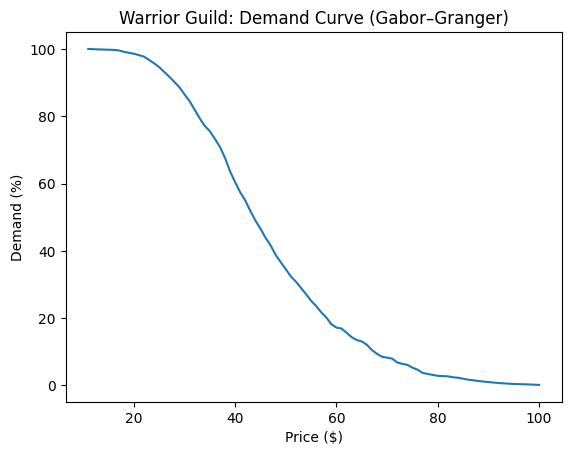

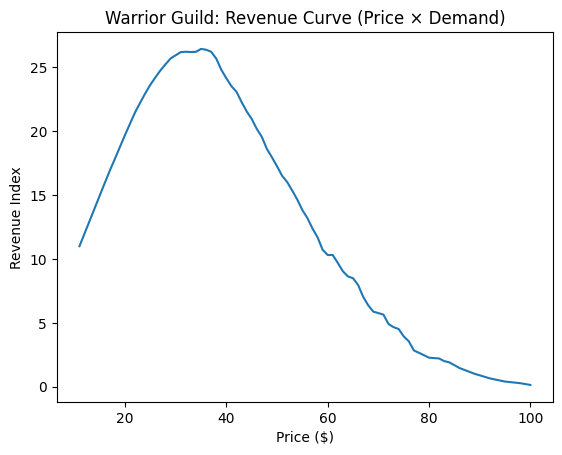

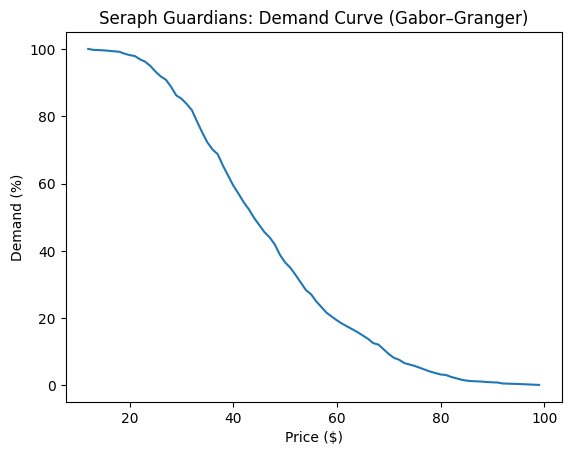

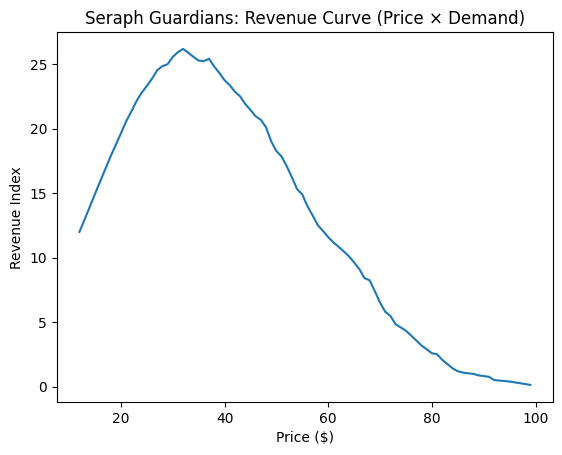

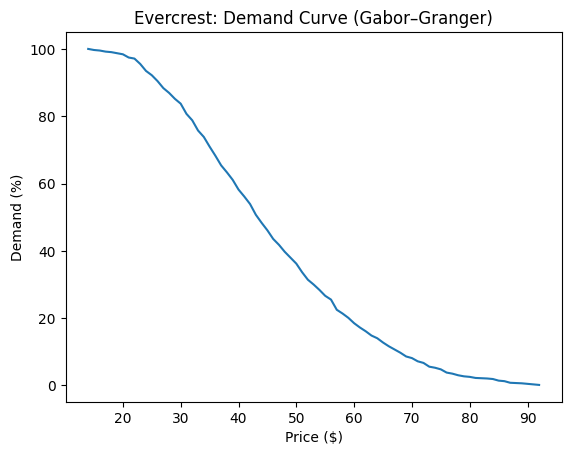

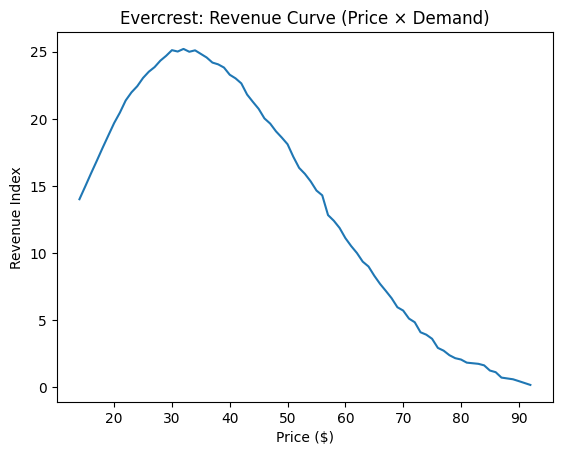

In [ ]:
import matplotlib.pyplot as plt

for game, info in results.items():
    curve = info["curve"]

    plt.figure()
    plt.plot(curve["price"], curve["demand_pct"])
    plt.title(f"{game}: Demand Curve (Gabor–Granger)")
    plt.xlabel("Price ($)")
    plt.ylabel("Demand (%)")
    plt.show()

    plt.figure()
    plt.plot(curve["price"], curve["revenue_index"])
    plt.title(f"{game}: Revenue Curve (Price × Demand)")
    plt.xlabel("Price ($)")
    plt.ylabel("Revenue Index")
    plt.show()

In [ ]:
import pandas as pd

factor_df = pd.read_csv("data_with_factor_scores.csv")
factor_df.columns

Index(['gender', 'state', 'age', 'income', 'imp.challenge', 'imp.unlocks',
       'imp.customize', 'imp.difficulty', 'imp.characters', 'imp.storyline',
       'imp.mastery', 'imp.backstory', 'imp.dominate', 'imp.completion',
       'imp.wealth', 'imp.fantasy', 'imp.items', 'imp.power', 'imp.offbeat',
       'imp.collect', 'enj.excitement', 'enj.destruction', 'enj.others',
       'enj.react', 'enj.duels', 'enj.strategy', 'enj.roleplay',
       'enj.competition', 'enj.decisions', 'enj.common.goal', 'enj.planning',
       'enj.immersion', 'enj.helping', 'enj.fast', 'enj.guns', 'enj.gore',
       'enj.blow.up', 'freq.explore', 'freq.experiment', 'freq.study',
       'freq.char.creation', 'freq.stats', 'freq.customize', 'freq.test.world',
       'gg.game.presented', 'gg.maxprice', 'rank.WarriorGuild',
       'rank.SeraphGuardians', 'rank.Evercrest', 'rank.DevilsGate',
       'rank.Marksman', 'rank.QuestoftheTitan', 'F1', 'F2', 'F3', 'F4', 'F5',
       'F6', 'F7', 'F8', 'F9', 'F10', 'F11'],


In [ ]:
from sklearn.cluster import KMeans

factor_cols = [c for c in factor_df.columns if c.startswith("F")]

kmeans = KMeans(n_clusters=8, random_state=42, n_init=50)
factor_df["segment"] = kmeans.fit_predict(factor_df[factor_cols])

In [ ]:
survey = pd.read_csv("Athena_survey_data.csv")

survey["segment"] = factor_df["segment"]

In [ ]:
survey["gg.maxprice"] = pd.to_numeric(survey["gg.maxprice"], errors="coerce")

reg_df = survey.dropna(subset=["gg.maxprice","gg.game.presented","segment"])
# Rename the column to a valid Python identifier for use in statsmodels formula
reg_df = reg_df.rename(columns={"gg.maxprice": "gg_maxprice"})

In [ ]:
import statsmodels.formula.api as smf

def run_regression(game):
    g = reg_df[reg_df["gg.game.presented"] == game]

    # Use the renamed column 'gg_maxprice'
    model = smf.ols("gg_maxprice ~ C(segment)", data=g).fit()
    print("\n", game)
    print(model.summary())

run_regression("Warrior Guild")
run_regression("Seraph Guardians")
run_regression("Evercrest")


 Warrior Guild
                            OLS Regression Results                            
Dep. Variable:            gg_maxprice   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     6.549
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           1.67e-07
Time:                        14:57:29   Log-Likelihood:                -2901.7
No. Observations:                 704   AIC:                             5819.
Df Residuals:                     696   BIC:                             5856.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          48.4842

In [ ]:
import pandas as pd

df = pd.read_csv("Athena_survey_data.csv")

rank_cols = [
    "rank.WarriorGuild",
    "rank.SeraphGuardians",
    "rank.Evercrest"
]

rank_df = df[rank_cols].dropna()
len(rank_df)

2178

In [ ]:
def first_choice(row):
    return row.idxmin()

rank_df["choice"] = rank_df.apply(first_choice, axis=1)

In [ ]:
rank_df["choice"] = rank_df["choice"].str.replace("rank.", "", regex=False)
rank_df["choice"]

,choice
0,WarriorGuild
1,SeraphGuardians
2,SeraphGuardians
3,SeraphGuardians
4,SeraphGuardians
...,...
2173,WarriorGuild
2174,SeraphGuardians
2175,SeraphGuardians
2176,WarriorGuild


In [ ]:
market_share = rank_df["choice"].value_counts(normalize=True) * 100
market_share

,proportion
choice,
SeraphGuardians,62.213039
WarriorGuild,27.410468
Evercrest,10.376492


In [ ]:
TOTAL_MARKET = 10_000_000

buyers = market_share / 100 * TOTAL_MARKET
buyers

,proportion
choice,
SeraphGuardians,6.221304e+06
WarriorGuild,2.741047e+06
Evercrest,1.037649e+06


In [ ]:
import pandas as pd

# -----------------------------
# Inputs from your 4b results
# -----------------------------
games = {
    "Warrior Guild": {"price": 35, "demand_pct": 75.6},
    "Seraph Guardians": {"price": 44.99, "demand_pct": 58.8},
    "Evercrest": {"price": 32, "demand_pct": 78.8}
}

TOTAL_MARKET = 10_000_000
CONVERSION = 0.30   # only 30% of "probably purchase"
ROYALTY_RATE = 0.05

# -----------------------------
# Steam tiered fee function
# -----------------------------
def steam_fee(gross):
    if gross <= 10_000_000:
        return 0.30 * gross
    elif gross <= 50_000_000:
        return 0.30 * 10_000_000 + 0.25 * (gross - 10_000_000)
    else:
        return (
            0.30 * 10_000_000 +
            0.25 * 40_000_000 +
            0.20 * (gross - 50_000_000)
        )

# -----------------------------
# Calculate revenues
# -----------------------------
results = []

for game, vals in games.items():
    price = vals["price"]
    demand = vals["demand_pct"] / 100

    # Apply 30% conversion
    buyers = TOTAL_MARKET * demand * CONVERSION

    # Gross revenue
    gross = buyers * price

    # Steam + royalty
    steam = steam_fee(gross)
    royalty = ROYALTY_RATE * gross

    # Net revenue
    net = gross - steam - royalty

    results.append({
        "Game": game,
        "Optimal Price": price,
        "Demand %": vals["demand_pct"],
        "Expected Buyers": round(buyers),
        "Gross Revenue ($)": gross,
        "Steam Fee ($)": steam,
        "Royalty ($)": royalty,
        "Net Revenue ($)": net
    })

financials = pd.DataFrame(results)
financials

,Game,Optimal Price,Demand %,Expected Buyers,Gross Revenue ($),Steam Fee ($),Royalty ($),Net Revenue ($)
0,Warrior Guild,35.00,75.6,2268000,79380000.0,18876000.0,3969000.0,56535000.0
1,Seraph Guardians,44.99,58.8,1764000,79362360.0,18872472.0,3968118.0,56521770.0
2,Evercrest,32.00,78.8,2364000,75648000.0,18129600.0,3782400.0,53736000.0


In [ ]:
import pandas as pd

df = pd.read_csv("Athena_survey_data.csv")

rank_cols = [
    'rank.WarriorGuild',
    'rank.SeraphGuardians',
    'rank.Evercrest',
    'rank.DevilsGate',
    'rank.Marksman',
    'rank.QuestoftheTitan'
]

# each respondent chooses the game they ranked #1
df['chosen_game'] = df[rank_cols].idxmin(axis=1)
df['chosen_game'] = df['chosen_game'].str.replace('rank.', '', regex=False)

# market share of each game
market_share = df['chosen_game'].value_counts(normalize=True) * 100
market_share = market_share.sort_index()

print(market_share)

chosen_game
DevilsGate         18.595041
Evercrest           9.779614
Marksman            2.295684
QuestoftheTitan     6.106520
SeraphGuardians    50.045914
WarriorGuild       13.177227
Name: proportion, dtype: float64


In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("Athena_survey_data.csv")

games = ["WarriorGuild","SeraphGuardians","Evercrest","DevilsGate","Marksman","QuestoftheTitan"]
rank_cols = [f"rank.{g}" for g in games]

# ----- USER-SET PARAMETERS -----
prices = {  # example: unequal prices
    "WarriorGuild": 29.99,
    "SeraphGuardians": 49.99,
    "Evercrest": 39.99,
    "DevilsGate": 49.99,
    "Marksman": 29.99,
    "QuestoftheTitan": 39.99
}

alpha = 1.0   # how strongly rank affects utility (bigger = ranks matter more)
beta  = 0.06  # price sensitivity (bigger = price matters more)

p0, p1, p2 = 0.20, 0.60, 0.20  # probabilities of buying 0 / 1 / 2 games
# -------------------------------

# Convert ranks to base utility (rank 1 highest). Simple: utility = -alpha * rank
base_u = -alpha * df[rank_cols].to_numpy()  # shape (n, 6)

# Price penalty: -beta * price
price_vec = np.array([prices[g] for g in games])
u = base_u - beta * price_vec  # broadcast price penalty

# Decide how many games each respondent buys: 0, 1, or 2
rng = np.random.default_rng(0)
buy_count = rng.choice([0,1,2], size=len(df), p=[p0,p1,p2])

# For each respondent, pick top-k games by utility
choices = []
for i in range(len(df)):
    k = buy_count[i]
    if k == 0:
        continue
    top_idx = np.argsort(u[i])[::-1][:k]  # descending utility
    for j in top_idx:
        choices.append(games[j])

# Market shares among purchases
shares = pd.Series(choices).value_counts(normalize=True) * 100
shares = shares.reindex(games).fillna(0)

print("Market share among purchases (%)")
print(shares)

# Athena shares under each action alternative (ONLY if Athena releases one game)
print("\nAthena share if only ONE title is released (action alternatives):")
for g in ["WarriorGuild","SeraphGuardians","Evercrest"]:
    print(f"Acquire {g}: {shares[g]:.2f}%")

Market share among purchases (%)
WarriorGuild       27.723690
SeraphGuardians    31.942513
Evercrest           9.272137
DevilsGate          8.669448
Marksman           12.934631
QuestoftheTitan     9.457580
Name: proportion, dtype: float64

Athena share if only ONE title is released (action alternatives):
Acquire WarriorGuild: 27.72%
Acquire SeraphGuardians: 31.94%
Acquire Evercrest: 9.27%


In [ ]:
# first choice (same as Q5a)
survey['chosen_game'] = df[rank_cols].idxmin(axis=1)
survey['chosen_game'] = survey['chosen_game'].str.replace('rank.', '', regex=False)

# market share within each segment
segment_share = pd.crosstab(survey['segment'], survey['chosen_game'], normalize='index') * 100
print(segment_share.round(2))

chosen_game  DevilsGate  Evercrest  Marksman  QuestoftheTitan  \
segment                                                         
0                  6.97       0.70      8.36             0.70   
1                  5.88      67.87      0.00             2.26   
2                  0.31       0.93      0.31            24.22   
3                  3.72       0.00      1.69            11.15   
4                 25.60       2.40      7.20             0.00   
5                 56.41       0.85      0.00             3.42   
6                 51.32       0.75      0.00             1.51   
7                  9.24      15.84      0.66             0.99   

chosen_game  SeraphGuardians  WarriorGuild  
segment                                     
0                      74.56          8.71  
1                      17.65          6.33  
2                      72.67          1.55  
3                      72.30         11.15  
4                      39.20         25.60  
5                       3.42      

In [ ]:
# store purchases with segment
purchase_df = pd.DataFrame({
    'game': choices
})

# need matching segments for each purchase
segments = []
i = 0
for idx in range(len(df)):
    k = buy_count[idx]
    for _ in range(k):
        segments.append(survey.loc[idx, 'segment'])

purchase_df['segment'] = segments

# segment-level shares
segment_sim_share = pd.crosstab(purchase_df['segment'], purchase_df['game'], normalize='index') * 100

print(segment_sim_share.round(2))

game     DevilsGate  Evercrest  Marksman  QuestoftheTitan  SeraphGuardians  \
segment                                                                      
0              6.12       2.04     42.18             4.42            31.97   
1              3.81      54.76      0.00             3.33            16.67   
2              0.32       1.60      4.17            31.73            58.65   
3              2.97       0.00     16.83            15.84            44.22   
4             12.75       4.38     22.31             0.80            17.13   
5             16.52       0.87      1.74             3.04             2.17   
6             25.98       1.18      3.94             4.33            29.92   
7              4.95      19.14      6.93             5.61            39.27   

game     WarriorGuild  
segment                
0               13.27  
1               21.43  
2                3.53  
3               20.13  
4               42.63  
5               75.65  
6               34.65  
7  

In [ ]:
games = ["WarriorGuild","SeraphGuardians","Evercrest","DevilsGate","Marksman","QuestoftheTitan"]
rank_cols = [f"rank.{g}" for g in games]

In [ ]:
df["chosen_game"] = df[rank_cols].idxmin(axis=1).str.replace("rank.","", regex=False)

overall_share = df["chosen_game"].value_counts(normalize=True) * 100
overall_share = overall_share.reindex(games).fillna(0)

overall_share.round(2)

,proportion
chosen_game,
WarriorGuild,13.18
SeraphGuardians,50.05
Evercrest,9.78
DevilsGate,18.60
Marksman,2.30
QuestoftheTitan,6.11


In [ ]:
segment_share = pd.crosstab(survey["segment"], survey["chosen_game"], normalize="index") * 100
segment_share = segment_share.reindex(columns=games).fillna(0)
segment_share.round(2)

chosen_game,WarriorGuild,SeraphGuardians,Evercrest,DevilsGate,Marksman,QuestoftheTitan
segment,,,,,,
0,8.71,74.56,0.70,6.97,8.36,0.70
1,6.33,17.65,67.87,5.88,0.00,2.26
2,1.55,72.67,0.93,0.31,0.31,24.22
3,11.15,72.30,0.00,3.72,1.69,11.15
4,25.60,39.20,2.40,25.60,7.20,0.00
5,35.90,3.42,0.85,56.41,0.00,3.42
6,6.04,40.38,0.75,51.32,0.00,1.51
7,15.18,58.09,15.84,9.24,0.66,0.99


In [ ]:
import numpy as np

# ----- set parameters -----
prices = {
    "WarriorGuild": 29.99,
    "SeraphGuardians": 49.99,
    "Evercrest": 39.99,
    "DevilsGate": 49.99,
    "Marksman": 29.99,
    "QuestoftheTitan": 39.99
}

alpha = 1.0   # rank importance
beta  = 0.06  # price sensitivity

p0, p1, p2 = 0.20, 0.60, 0.20  # buy 0/1/2 games
rng = np.random.default_rng(0)
# --------------------------

# utility matrix: higher = better
base_u = -alpha * df[rank_cols].to_numpy()
price_vec = np.array([prices[g] for g in games])
u = base_u - beta * price_vec

buy_count = rng.choice([0,1,2], size=len(df), p=[p0,p1,p2])

# simulate purchases
purchase_rows = []
for i in range(len(df)):
    k = buy_count[i]
    if k == 0:
        continue
    top_idx = np.argsort(u[i])[::-1][:k]
    for j in top_idx:
        purchase_rows.append({
            "segment": survey.loc[i, "segment"],   # change to "cluster" if needed
            "game": games[j]
        })

purchase_df = pd.DataFrame(purchase_rows)

# overall simulated shares
sim_share = purchase_df["game"].value_counts(normalize=True) * 100
sim_share = sim_share.reindex(games).fillna(0)

print("Overall simulated market share (%)")
print(sim_share.round(2))

# segment simulated shares
seg_sim_share = pd.crosstab(purchase_df["segment"], purchase_df["game"], normalize="index") * 100
seg_sim_share = seg_sim_share.reindex(columns=games).fillna(0)

print("\nSimulated shares by segment (%)")
display(seg_sim_share.round(2))

# Athena shares under each action alternative
print("\nAthena share if only ONE title is released:")
for g in ["WarriorGuild","SeraphGuardians","Evercrest"]:
    print(f"Acquire {g}: {sim_share[g]:.2f}%")

Overall simulated market share (%)
game
WarriorGuild       27.72
SeraphGuardians    31.94
Evercrest           9.27
DevilsGate          8.67
Marksman           12.93
QuestoftheTitan     9.46
Name: proportion, dtype: float64

Simulated shares by segment (%)


game,WarriorGuild,SeraphGuardians,Evercrest,DevilsGate,Marksman,QuestoftheTitan
segment,,,,,,
0,13.27,31.97,2.04,6.12,42.18,4.42
1,21.43,16.67,54.76,3.81,0.00,3.33
2,3.53,58.65,1.60,0.32,4.17,31.73
3,20.13,44.22,0.00,2.97,16.83,15.84
4,42.63,17.13,4.38,12.75,22.31,0.80
5,75.65,2.17,0.87,16.52,1.74,3.04
6,34.65,29.92,1.18,25.98,3.94,4.33
7,24.09,39.27,19.14,4.95,6.93,5.61



Athena share if only ONE title is released:
Acquire WarriorGuild: 27.72%
Acquire SeraphGuardians: 31.94%
Acquire Evercrest: 9.27%
